<style>
body {
  background-color: #eef2f6;
}
.quarto-title-block, .content {
  background-color: #f7f5ef;
}
h1, h2 {
  color: #1f4e79;
}
</style>

## Introduction

An analysis of COVID-19 outcomes across **Ireland** and 9 other countries (2020–2022), prepared for the **National Public Health Emergency Team (NPHET)**.

Vaccination is often assumed to be the main driver of pandemic outcomes, but is that the whole story? This report compares Ireland against Afghanistan, Bonaire Sint Eustatius and Saba, Bosnia and Herzegovina, Croatia, Cuba, Latvia, Mongolia, Saint Pierre and Miquelon, and Sao Tome and Principe to find out.

> **Key finding:** Ireland's high vaccination rate (approximately 81%) coincided with comparatively low mortality, but vaccination alone doesn't explain everything. Cuba matched Ireland's vaccination rate yet had far fewer deaths, while Bosnia and Herzegovina had the *highest* deaths per million despite only moderate vaccination, pointing to **healthcare system capacity** as another key factor.

## Data and Setup

In [3]:
install.packages(c("tidyverse", "sf", "rnaturalearth", "rnaturalearthdata", "ggrepel", "scales"))

library(tidyverse)
library(sf)
library(rnaturalearth)
library(rnaturalearthdata)
library(ggrepel)
library(scales)

country_data     <- read_csv("country_data.csv")
country_metadata <- read_csv("country_metadata.csv")

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Rows: 10920 Columns: 52
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (4): iso_code, continent, location, tests_units
dbl  (47): total_cases, new_cases, new_cases_smoothed, total_deaths, new_dea...
date  (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 10 Columns: 16
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): location
dbl (15): stringency_index, population_density, median_age, aged_65_older, a...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


The `country_data.csv` file contains daily COVID-19 records (cases, deaths, testing, vaccination) from 2020-01-05 to 2022-12-31 for Ireland and 9 comparator countries. `country_metadata.csv` contains static per-country indicators (e.g., population density, GDP per capita, hospital beds per thousand).

In [4]:
# Helper: last non-missing value in a (date-ordered) vector
last_known <- function(x) {
  x <- x[!is.na(x)]
  if (length(x) == 0) return(NA_real_)
  x[length(x)]
}

country_summary <- country_data |>
  arrange(location, date) |>
  group_by(location, continent, iso_code) |>
  summarise(
    total_cases_per_million             = last_known(total_cases_per_million),
    total_deaths_per_million            = last_known(total_deaths_per_million),
    people_fully_vaccinated_per_hundred = last_known(people_fully_vaccinated_per_hundred),
    .groups = "drop"
  ) |>
  left_join(country_metadata, by = "location") |>
  mutate(is_ireland = location == "Ireland")



::: {.callout-note}
**Data quality note:** Saint Pierre and Miquelon has no reported vaccination data across the full period, so it is excluded from the vaccination-vs-deaths analysis below. Its very small population also means its *per-million* case rate is extremely volatile (a handful of cases produces huge swings), which is addressed in the time-series chart via faceting rather than a shared axis.
:::

## World Map: Total Cases per Million

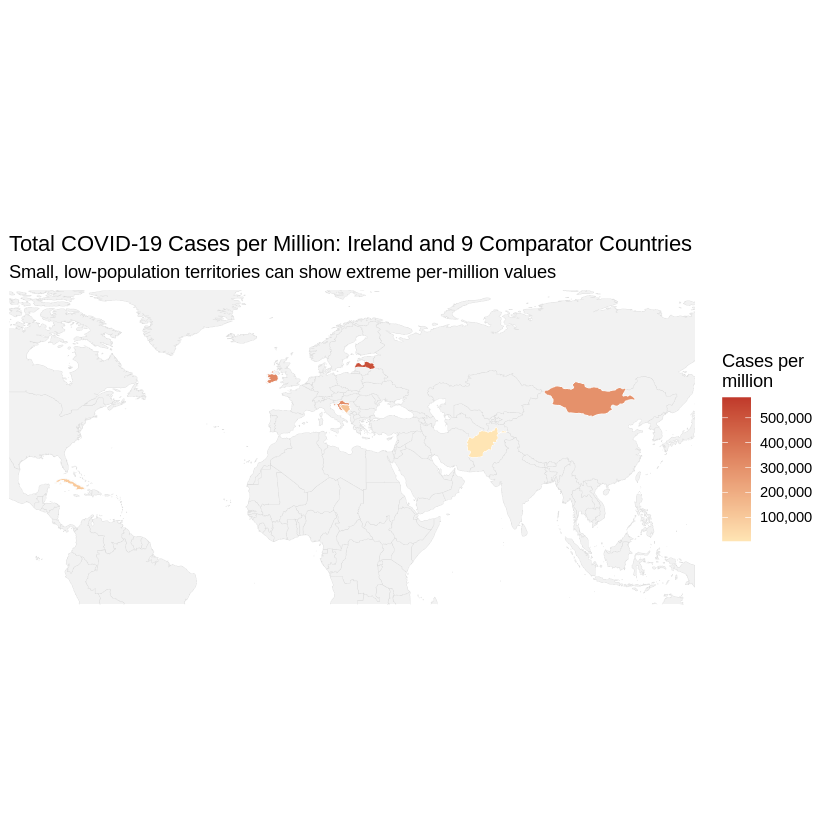

In [6]:
#| label: fig-map
#| fig-cap: "Total COVID-19 cases per million people (2020-2022), for Ireland and 9 comparator countries."
#| fig-width: 11
#| fig-height: 6.5
world <- ne_countries(scale = "medium", returnclass = "sf")

ggplot() +
  geom_sf(data = world, fill = "grey95", color = "grey85", linewidth = 0.1) +
  geom_sf(
    data = world |> inner_join(country_summary, by = c("iso_a3" = "iso_code")),
    aes(fill = total_cases_per_million),
    color = "white", linewidth = 0.2
  ) +
  scale_fill_gradient(
    low = "#ffe5b4", high = "#c0392b",
    name = "Cases per\nmillion",
    labels = comma
  ) +
  coord_sf(xlim = c(-90, 130), ylim = c(-10, 75)) +
  labs(
    title = "Total COVID-19 Cases per Million: Ireland and 9 Comparator Countries",
    subtitle = "Small, low-population territories can show extreme per-million values"
  ) +
  theme_minimal() +
  theme(
    axis.text = element_blank(),
    axis.title = element_blank(),
    panel.grid = element_blank()
  )

::: {.callout-important}
**Note:** Small island/dependent territories (Bonaire Sint Eustatius and Saba, Saint Pierre and Miquelon) may not render as separately-coloured polygons at `scale = "medium"` resolution, as Natural Earth's medium-detail map does not always include them as distinct shapes.
:::

## Bar Chart: Total Deaths per Million

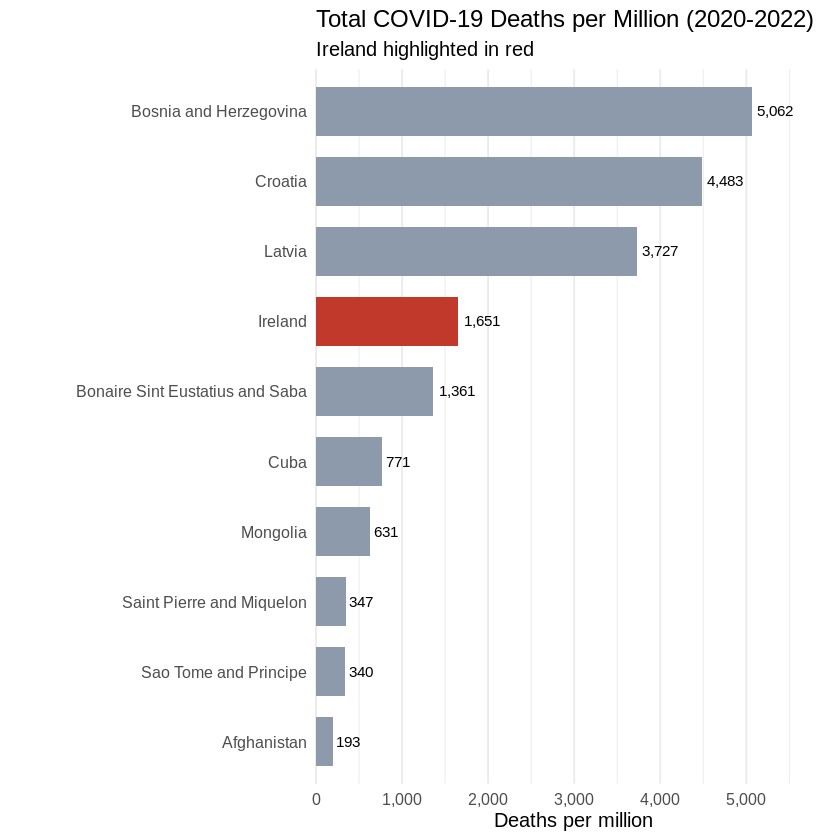

In [7]:
#| label: fig-bar
#| fig-cap: "Total COVID-19 deaths per million by country, ranked highest to lowest. Ireland highlighted in red."

ggplot(country_summary, aes(
  x = reorder(location, total_deaths_per_million),
  y = total_deaths_per_million,
  fill = is_ireland
)) +
  geom_col(width = 0.7) +
  geom_text(aes(label = comma(round(total_deaths_per_million))), hjust = -0.15, size = 3.2) +
  coord_flip(clip = "off") +
  scale_fill_manual(values = c("TRUE" = "#c0392b", "FALSE" = "#8c9aab"), guide = "none") +
  scale_y_continuous(expand = expansion(mult = c(0, 0.18)), labels = comma) +
  labs(
    title = "Total COVID-19 Deaths per Million (2020-2022)",
    subtitle = "Ireland highlighted in red",
    x = NULL,
    y = "Deaths per million"
  ) +
  theme_minimal(base_size = 12) +
  theme(panel.grid.major.y = element_blank())

Bosnia and Herzegovina recorded by far the highest death toll per million among the ten countries, over three times Ireland's rate, despite similar or even lower vaccination coverage than some countries with fewer deaths. This points toward healthcare system capacity, rather than vaccination alone, as a major differentiator.

## Scatterplot: Vaccination Rate vs. Deaths per Million

`geom_smooth()` using formula = 'y ~ x'


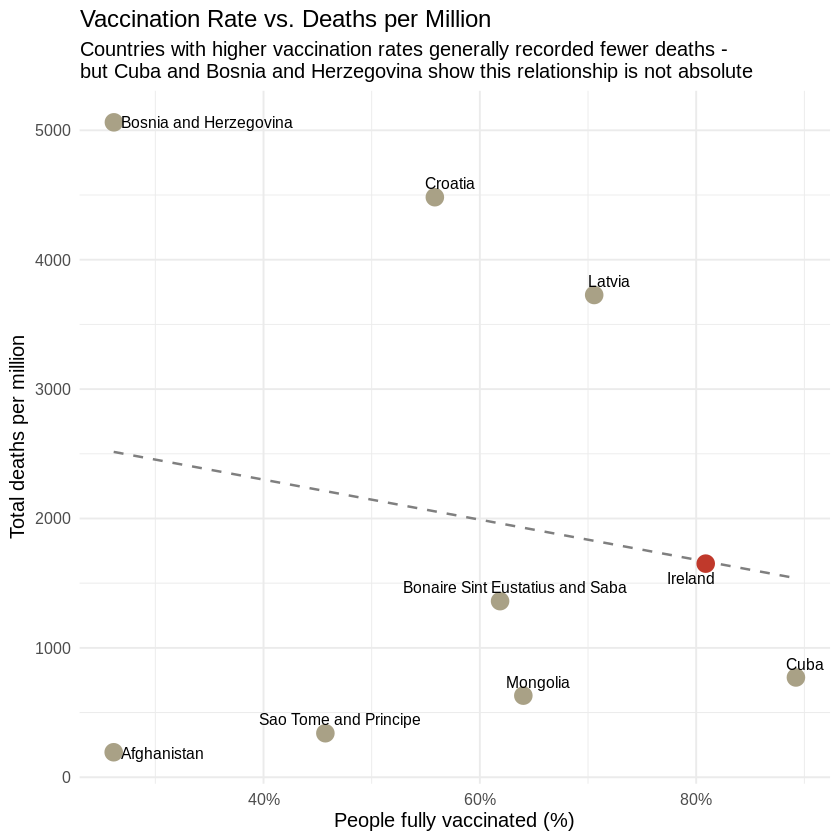

In [8]:
#| label: fig-scatter
#| fig-cap: "Relationship between full vaccination coverage and total deaths per million, with a linear regression line."

vax_data <- country_summary |>
  filter(!is.na(people_fully_vaccinated_per_hundred))

ggplot(vax_data, aes(x = people_fully_vaccinated_per_hundred, y = total_deaths_per_million)) +
  geom_smooth(method = "lm", se = FALSE, color = "grey50", linetype = "dashed", linewidth = 0.7) +
  geom_point(aes(color = is_ireland), size = 4.5) +
  geom_text_repel(aes(label = location), size = 3.3, seed = 1) +
  scale_color_manual(values = c("TRUE" = "#c0392b", "FALSE" = "#a9a186"), guide = "none") +
  scale_x_continuous(labels = function(x) paste0(x, "%")) +
  labs(
    title = "Vaccination Rate vs. Deaths per Million",
    subtitle = "Countries with higher vaccination rates generally recorded fewer deaths -\nbut Cuba and Bosnia and Herzegovina show this relationship is not absolute",
    x = "People fully vaccinated (%)",
    y = "Total deaths per million"
  ) +
  theme_minimal(base_size = 12)

Ireland's high vaccination rate (approximatel 81%) sits alongside a comparatively low death rate, consistent with effective vaccine rollout. However, **Cuba reached a similar vaccination rate (approoximately 89%) yet recorded a much lower death rate than Ireland**, while **Bosnia and Herzegovina's death rate was the highest in the group despite only moderate vaccination (approximately 26%)**. Evidence that vaccination coverage alone does not fully explain outcomes; healthcare capacity and reporting practices are also likely contributors.

## Time-Series: Daily New Cases (Smoothed)

Warning message:
“Removed 50 rows containing missing values or values outside the scale range
(`geom_line()`).”


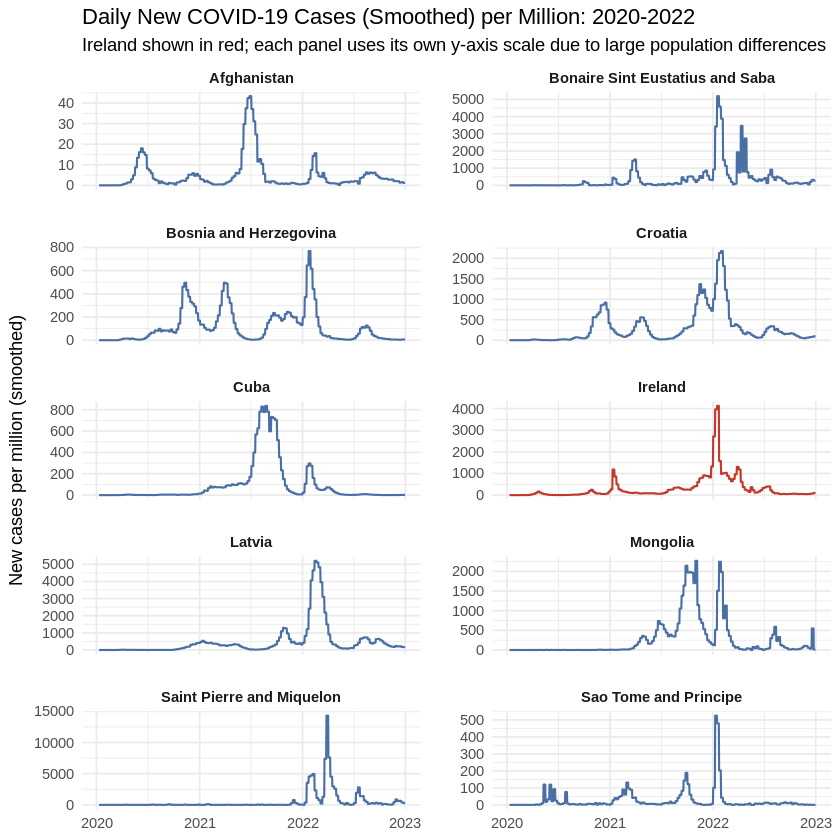

In [12]:
#| label: fig-timeseries
#| fig-cap: "7-day smoothed new COVID-19 cases per million, faceted by country (free y-axis scales due to large differences in population size)."
#| fig-height: 10

ggplot(country_data, aes(x = date, y = new_cases_smoothed_per_million)) +
  geom_line(aes(color = location == "Ireland"), linewidth = 0.6) +
  facet_wrap(~location, scales = "free_y", ncol = 2) +
  scale_color_manual(values = c("TRUE" = "#c0392b", "FALSE" = "#4a6fa5"), guide = "none") +
  scale_x_date(date_labels = "%Y", date_breaks = "1 year") +
  labs(
    title = "Daily New COVID-19 Cases (Smoothed) per Million: 2020-2022",
    subtitle = "Ireland shown in red; each panel uses its own y-axis scale due to large population differences",
    x = NULL,
    y = "New cases per million (smoothed)"
  ) +
theme_minimal(base_size = 11) +
  theme(
    strip.text = element_text(face = "bold"),
    panel.spacing = unit(1.2, "lines")
  )

Free y-axis scales are used deliberately here: Saint Pierre and Miquelon's tiny population means a handful of daily cases can register as an extreme per-million spike, which would otherwise flatten every other country's trend on a shared axis. Ireland shows clear, repeated waves which is most notably the large Omicron-driven peak in early 2022, broadly in line with the pattern seen across the other European comparators (Croatia, Latvia, Bosnia and Herzegovina).

## Conclusion

Across the ten countries studied, Ireland's pandemic response, anchored by a high vaccination rate, coincided with comparatively favourable mortality outcomes. However, this comparison also shows that **vaccination rate alone is an incomplete predictor of pandemic outcomes**:

- **Cuba** matched Ireland's vaccination coverage but recorded fewer deaths per million, suggesting other factors (e.g. population age structure, healthcare access) also shaped outcomes.
- **Bosnia and Herzegovina** recorded the highest death rate in the group despite only moderate vaccination coverage, pointing to healthcare capacity constraints as a likely contributing factor.
- **Afghanistan's** very low reported death rate is more plausibly explained by limited testing and reporting infrastructure than by genuinely low mortality.

**For NPHET:** these findings suggest that future pandemic preparedness should weigh healthcare system capacity and surveillance/reporting infrastructure alongside vaccination programmes, rather than treating vaccination coverage as a standalone predictor of outcomes.